# 📊 Dataset Information

**Note:** The dataset for this project is **not included in this repository** to keep the repository lightweight.  

You can download the dataset from **Kaggle** using the link below:  

[Download The Crypto Perp Liquidations Dataset](https://www.kaggle.com/datasets/sergionefedov/crypto-perp-liquidations-who-survives?select=crypto_perp_liquidations.csv)  

Please make sure to place the downloaded CSV file in the same directory as this notebook before running any code.

# Importing

## Import Library

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

## Import CSV And convert to DataFrame

In [2]:
df = pd.read_csv('crypto_perp_liquidations.csv')

# Preprocessing

## Frist five row

In [3]:
df.head()

,position_id,asset,position_side,leverage,margin_mode,notional_usd,initial_margin,init_margin_rate,maint_margin_rate,liq_distance_pct,vol_regime,hourly_volatility,funding_rate_8h,adds_margin,uses_stop_loss,intended_hold_hours,time_to_liquidation_hours,pnl_pct,got_liquidated,survived
0,POS000000,ARB,long,18,isolated,3333.0,185.17,0.0556,0.0278,2.778,calm,0.0108,-0.00028,0,1,14,12.0,-100.0,1,0
1,POS000001,BTC,long,23,isolated,5868.0,255.13,0.0435,0.0217,2.174,calm,0.0048,0.00034,0,1,16,NaN,35.3,0,1
2,POS000002,BTC,long,59,cross,1828.0,30.98,0.0169,0.0085,0.847,normal,0.0080,0.00077,0,1,52,17.0,-100.0,1,0
3,POS000003,ETH,long,12,cross,1946.0,162.17,0.0833,0.0417,4.167,normal,0.0100,0.00021,0,1,36,NaN,-27.3,0,1
4,POS000004,DOGE,short,50,isolated,6411.0,128.22,0.0200,0.0100,1.000,normal,0.0220,0.00014,0,0,25,1.0,-100.0,1,0


## last Five row

In [4]:
df.tail()

,position_id,asset,position_side,leverage,margin_mode,notional_usd,initial_margin,init_margin_rate,maint_margin_rate,liq_distance_pct,vol_regime,hourly_volatility,funding_rate_8h,adds_margin,uses_stop_loss,intended_hold_hours,time_to_liquidation_hours,pnl_pct,got_liquidated,survived
59995,POS059995,DOGE,long,34,cross,9976.0,293.41,0.0294,0.0147,1.471,normal,0.022,0.00007,0,1,12,NaN,-100.0,0,1
59996,POS059996,ETH,long,40,cross,21667.0,541.67,0.0250,0.0125,1.250,calm,0.006,0.00001,1,0,42,18.0,-100.0,1,0
59997,POS059997,BTC,long,98,isolated,5499.0,56.11,0.0102,0.0051,0.510,normal,0.008,0.00073,1,0,9,NaN,238.2,0,1
59998,POS059998,HYPE,long,52,isolated,7041.0,135.40,0.0192,0.0096,0.962,calm,0.012,0.00025,1,0,70,13.0,-100.0,1,0
59999,POS059999,altcoin_smallcap,long,22,isolated,5511.0,250.50,0.0455,0.0227,2.273,calm,0.018,0.00038,0,1,49,NaN,-31.1,0,1


## Shape of our dataset

In [5]:
df.shape

(60000, 20)

## List out all columns

In [6]:
df.columns

Index(['position_id', 'asset', 'position_side', 'leverage', 'margin_mode',
       'notional_usd', 'initial_margin', 'init_margin_rate',
       'maint_margin_rate', 'liq_distance_pct', 'vol_regime',
       'hourly_volatility', 'funding_rate_8h', 'adds_margin', 'uses_stop_loss',
       'intended_hold_hours', 'time_to_liquidation_hours', 'pnl_pct',
       'got_liquidated', 'survived'],
      dtype='object')

## Datatype of each columns

In [7]:
df.dtypes

position_id                   object
asset                         object
position_side                 object
leverage                       int64
margin_mode                   object
notional_usd                 float64
initial_margin               float64
init_margin_rate             float64
maint_margin_rate            float64
liq_distance_pct             float64
vol_regime                    object
hourly_volatility            float64
funding_rate_8h              float64
adds_margin                    int64
uses_stop_loss                 int64
intended_hold_hours            int64
time_to_liquidation_hours    float64
pnl_pct                      float64
got_liquidated                 int64
survived                       int64
dtype: object

## Information of all Columns

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 60000 entries, 0 to 59999
Data columns (total 20 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   position_id                60000 non-null  object 
 1   asset                      60000 non-null  object 
 2   position_side              60000 non-null  object 
 3   leverage                   60000 non-null  int64  
 4   margin_mode                60000 non-null  object 
 5   notional_usd               60000 non-null  float64
 6   initial_margin             60000 non-null  float64
 7   init_margin_rate           60000 non-null  float64
 8   maint_margin_rate          60000 non-null  float64
 9   liq_distance_pct           60000 non-null  float64
 10  vol_regime                 60000 non-null  object 
 11  hourly_volatility          60000 non-null  float64
 12  funding_rate_8h            60000 non-null  float64
 13  adds_margin                60000 non-null  int

## Check Null Value

In [9]:
df.isnull().sum()

position_id                      0
asset                            0
position_side                    0
leverage                         0
margin_mode                      0
notional_usd                     0
initial_margin                   0
init_margin_rate                 0
maint_margin_rate                0
liq_distance_pct                 0
vol_regime                       0
hourly_volatility                0
funding_rate_8h                  0
adds_margin                      0
uses_stop_loss                   0
intended_hold_hours              0
time_to_liquidation_hours    36876
pnl_pct                          0
got_liquidated                   0
survived                         0
dtype: int64

## Drop Null Feachers

In [10]:
df.drop(columns=['time_to_liquidation_hours'], inplace=True)

## Check Dupicate Value

In [11]:
df.duplicated().sum()

np.int64(0)

## Summary

In [12]:
df.describe()

,leverage,notional_usd,initial_margin,init_margin_rate,maint_margin_rate,liq_distance_pct,hourly_volatility,funding_rate_8h,adds_margin,uses_stop_loss,intended_hold_hours,pnl_pct,got_liquidated,survived
count,60000.000000,60000.000000,60000.000000,60000.000000,60000.000000,60000.000000,60000.000000,60000.000000,60000.00000,60000.000000,60000.000000,60000.000000,60000.000000,60000.000000
mean,38.347417,7204.663783,318.074661,0.044093,0.022044,2.204727,0.018558,0.000226,0.29840,0.444917,18.267750,7.829693,0.385400,0.614600
std,24.065467,5355.766052,550.351698,0.054198,0.027100,2.709862,0.014663,0.000462,0.45756,0.496961,15.916734,207.264562,0.486694,0.486694
min,1.000000,50.000000,0.490000,0.008000,0.004000,0.400000,0.004800,-0.001450,0.00000,0.000000,1.000000,-100.000000,0.000000,0.000000
25%,20.000000,3287.000000,86.640000,0.019600,0.009800,0.980000,0.009000,-0.000090,0.00000,0.000000,7.000000,-100.000000,0.000000,0.000000
50%,33.000000,5942.000000,177.390000,0.030300,0.015200,1.515000,0.014400,0.000210,0.00000,0.000000,14.000000,-48.600000,0.000000,1.000000
75%,51.000000,9764.500000,357.830000,0.050000,0.025000,2.500000,0.022000,0.000520,1.00000,1.000000,25.000000,28.300000,1.000000,1.000000
max,125.000000,72465.000000,35270.000000,1.000000,0.500000,50.000000,0.096000,0.002220,1.00000,1.000000,151.000000,2000.000000,1.000000,1.000000


# EDA

In [13]:
def show_fig():
    plt.tight_layout()
    plt.show()

plot_no = 1

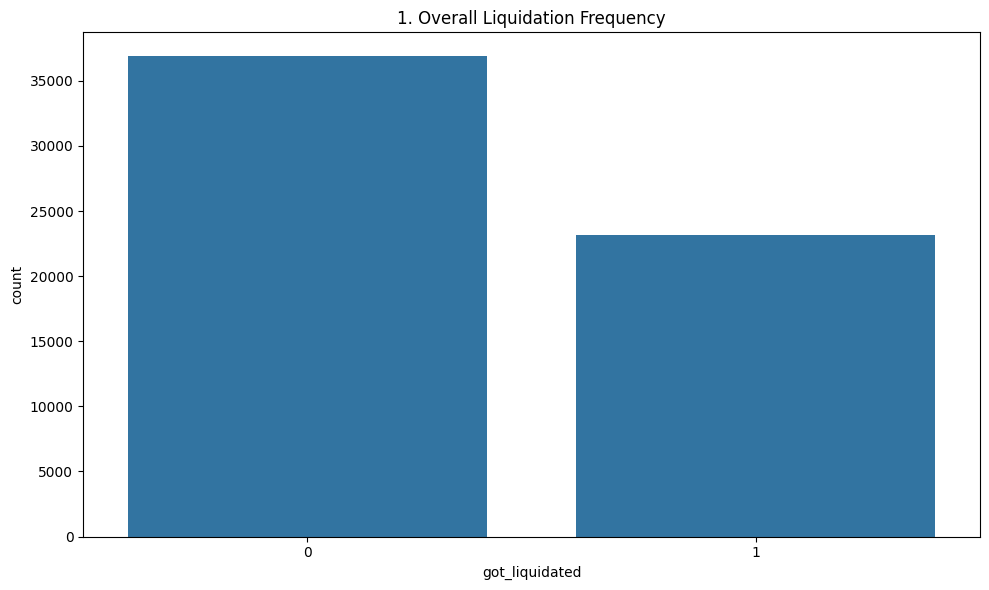

In [14]:
fig = plt.figure(figsize=(10,6))
sns.countplot(data=df, x='got_liquidated')
plt.title(f'{plot_no}. Overall Liquidation Frequency')
show_fig()
plot_no += 1

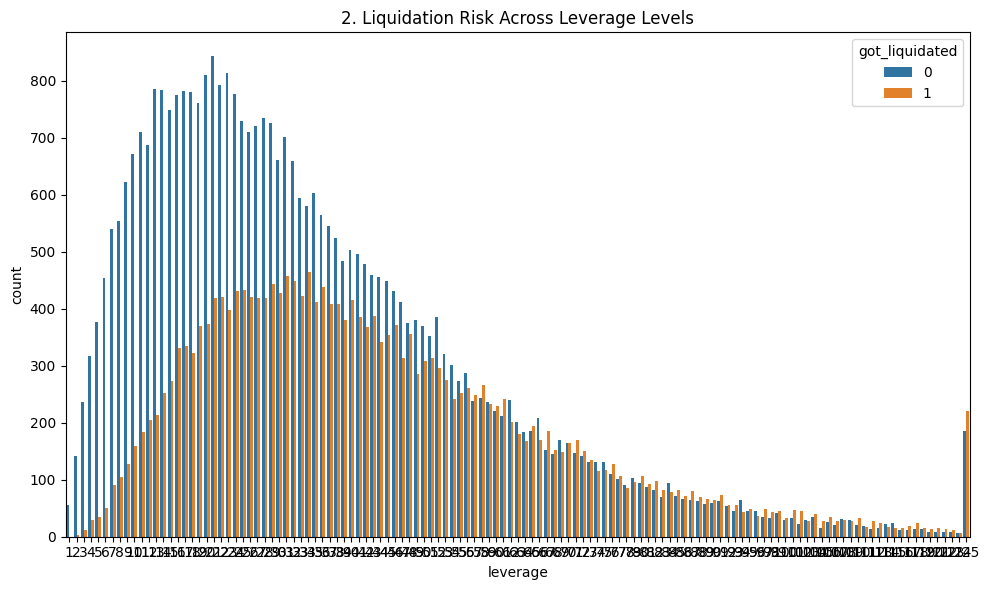

In [15]:
fig = plt.figure(figsize=(10,6))
sns.countplot(data=df, x='leverage', hue='got_liquidated')
plt.title(f'{plot_no}. Liquidation Risk Across Leverage Levels')
show_fig()
plot_no += 1

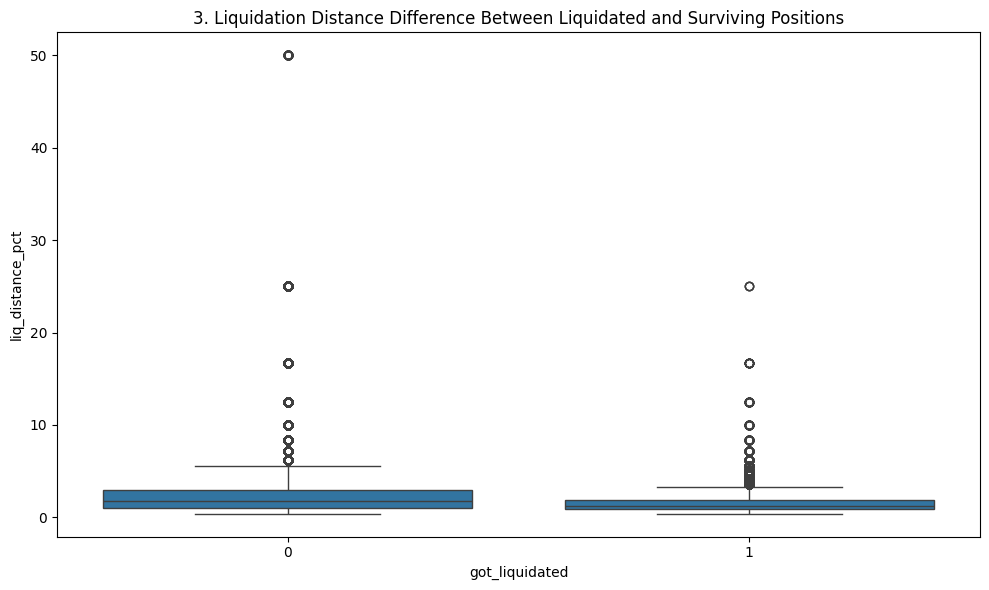

In [16]:
fig = plt.figure(figsize=(10,6))
sns.boxplot(data=df, x='got_liquidated', y='liq_distance_pct')
plt.title(f'{plot_no}. Liquidation Distance Difference Between Liquidated and Surviving Positions')
show_fig()
plot_no += 1

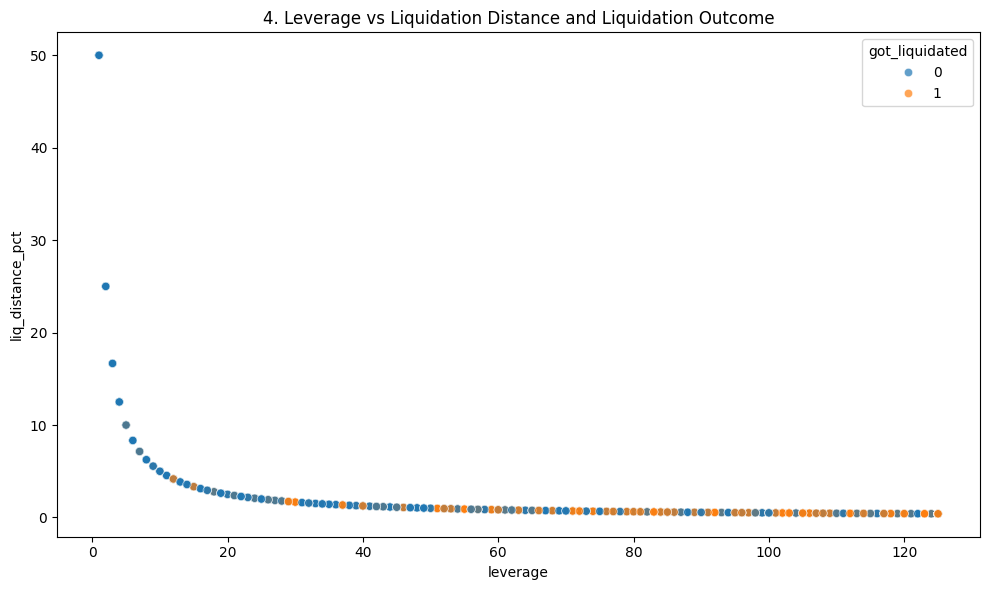

In [17]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='leverage', y='liq_distance_pct', hue='got_liquidated', alpha=0.7)
plt.title(f'{plot_no}. Leverage vs Liquidation Distance and Liquidation Outcome')
show_fig()
plot_no += 1

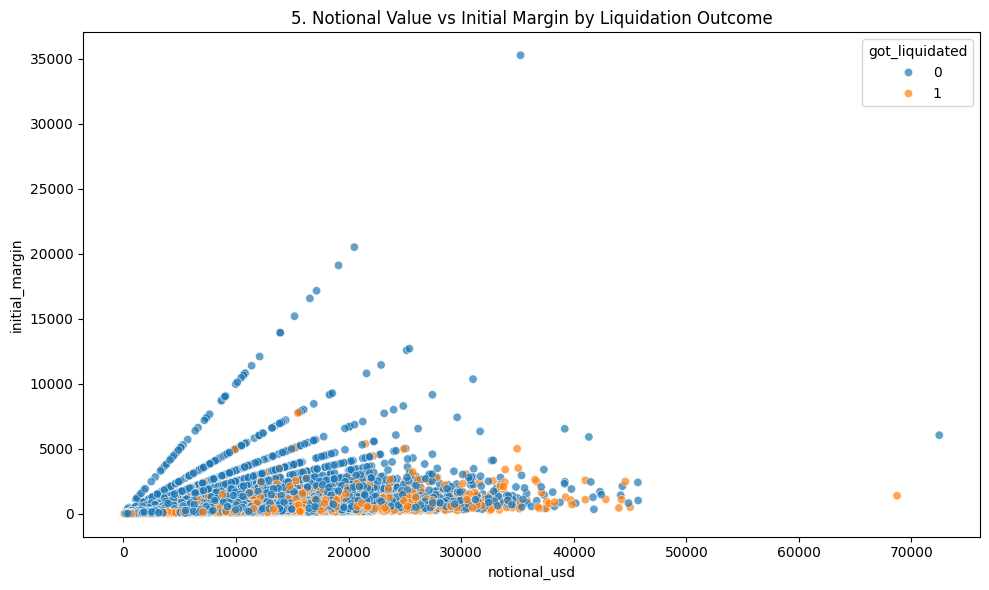

In [18]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='notional_usd', y='initial_margin', hue='got_liquidated', alpha=0.7)
plt.title(f'{plot_no}. Notional Value vs Initial Margin by Liquidation Outcome')
show_fig()
plot_no += 1

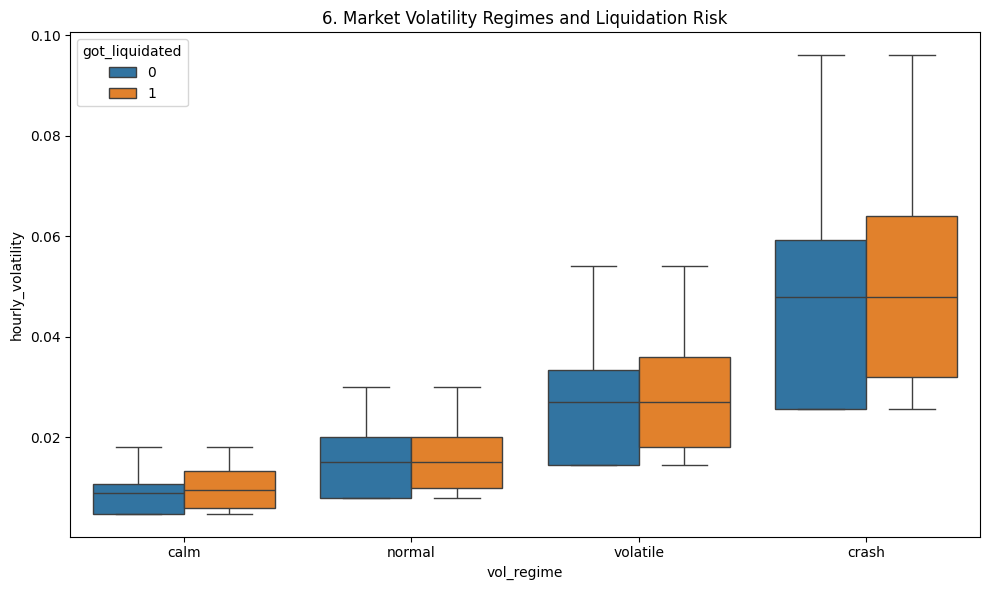

In [19]:
fig = plt.figure(figsize=(10,6))
sns.boxplot(data=df, x='vol_regime', y='hourly_volatility', hue='got_liquidated')
plt.title(f'{plot_no}. Market Volatility Regimes and Liquidation Risk')
show_fig()
plot_no += 1

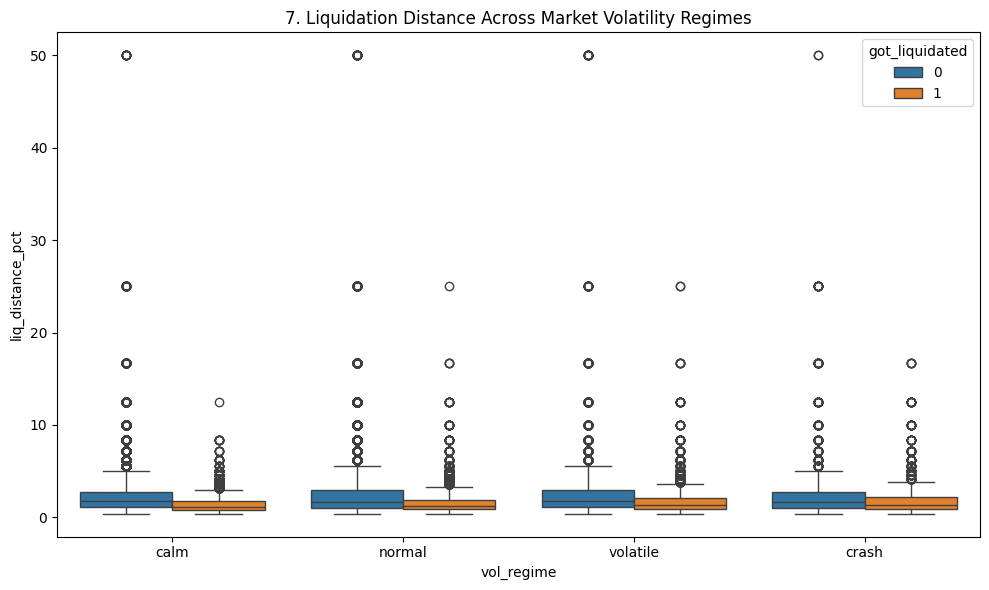

In [20]:
fig = plt.figure(figsize=(10,6))
sns.boxplot(data=df, x='vol_regime', y='liq_distance_pct', hue='got_liquidated')
plt.title(f'{plot_no}. Liquidation Distance Across Market Volatility Regimes')
show_fig()
plot_no += 1

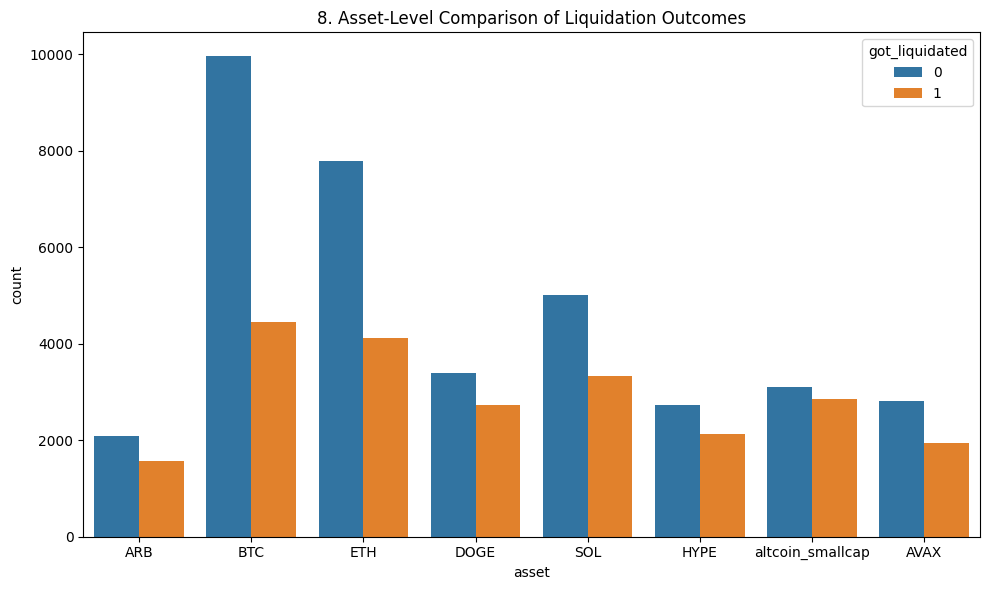

In [21]:
fig = plt.figure(figsize=(10,6))
sns.countplot(data=df, x='asset', hue='got_liquidated')
plt.title(f'{plot_no}. Asset-Level Comparison of Liquidation Outcomes')
show_fig()
plot_no += 1

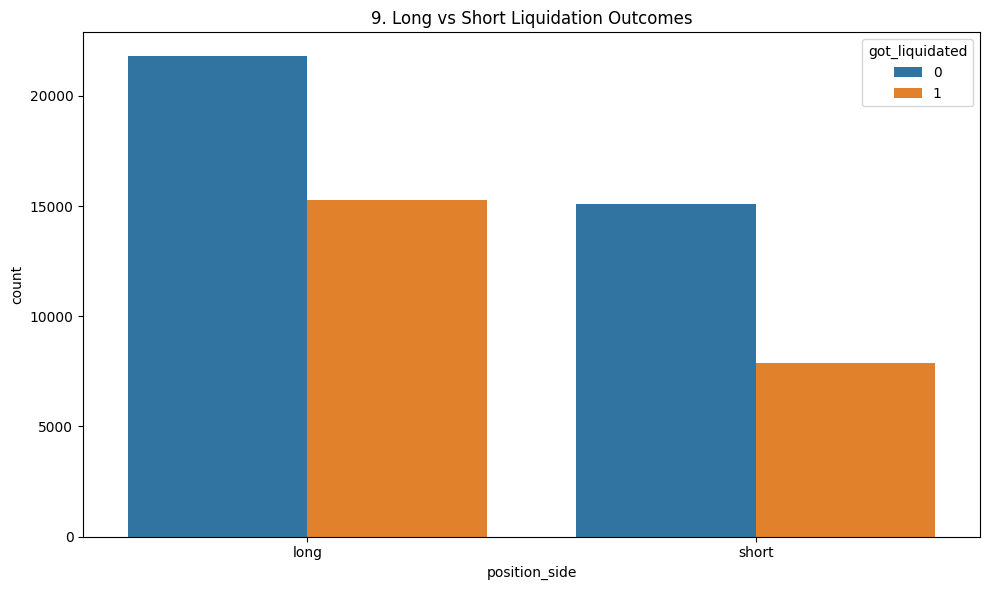

In [22]:
fig = plt.figure(figsize=(10,6))
sns.countplot(data=df, x='position_side', hue='got_liquidated')
plt.title(f'{plot_no}. Long vs Short Liquidation Outcomes')
show_fig()
plot_no += 1

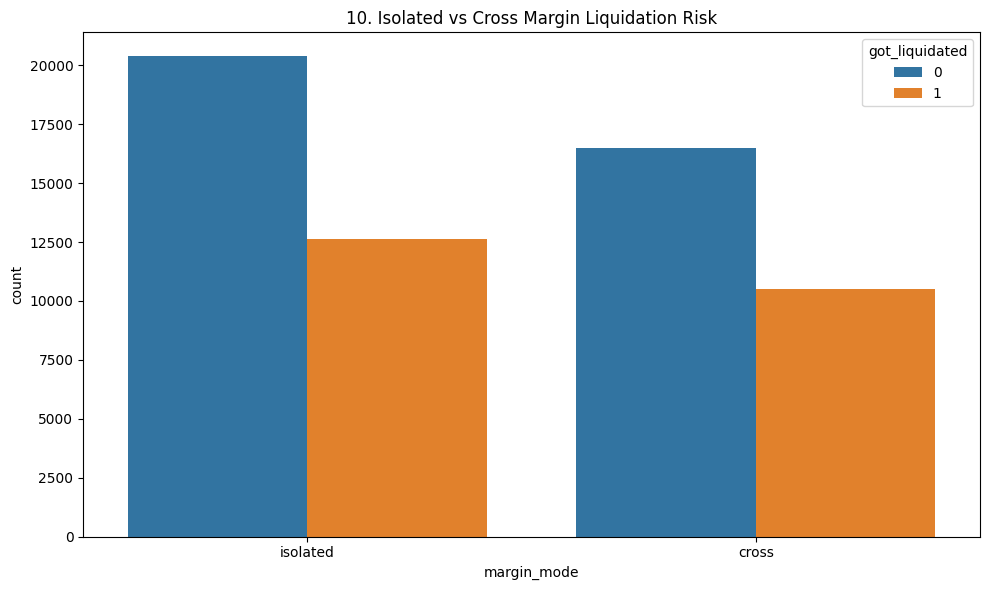

In [23]:
fig = plt.figure(figsize=(10,6))
sns.countplot(data=df, x='margin_mode', hue='got_liquidated')
plt.title(f'{plot_no}. Isolated vs Cross Margin Liquidation Risk')
show_fig()
plot_no += 1

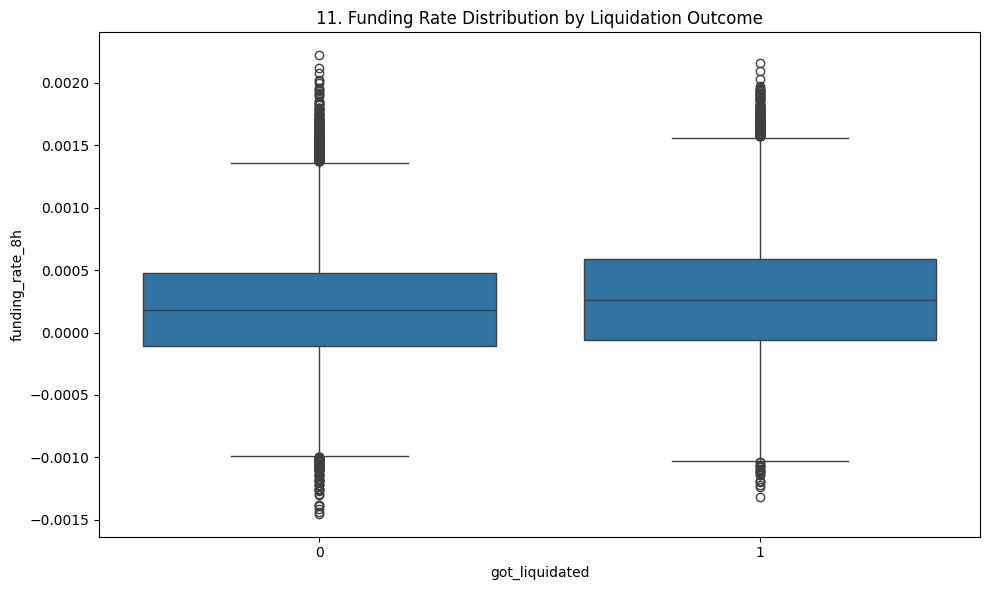

In [24]:
fig = plt.figure(figsize=(10,6))
sns.boxplot(data=df, x='got_liquidated', y='funding_rate_8h')
plt.title(f'{plot_no}. Funding Rate Distribution by Liquidation Outcome')
show_fig()
plot_no += 1

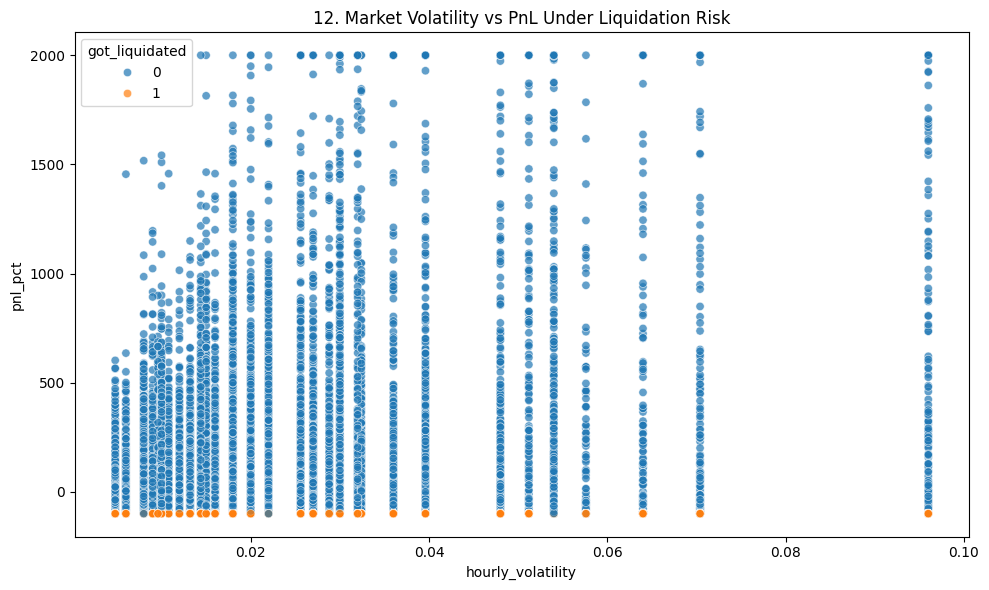

In [25]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='hourly_volatility', y='pnl_pct', hue='got_liquidated', alpha=0.7)
plt.title(f'{plot_no}. Market Volatility vs PnL Under Liquidation Risk')
show_fig()
plot_no += 1

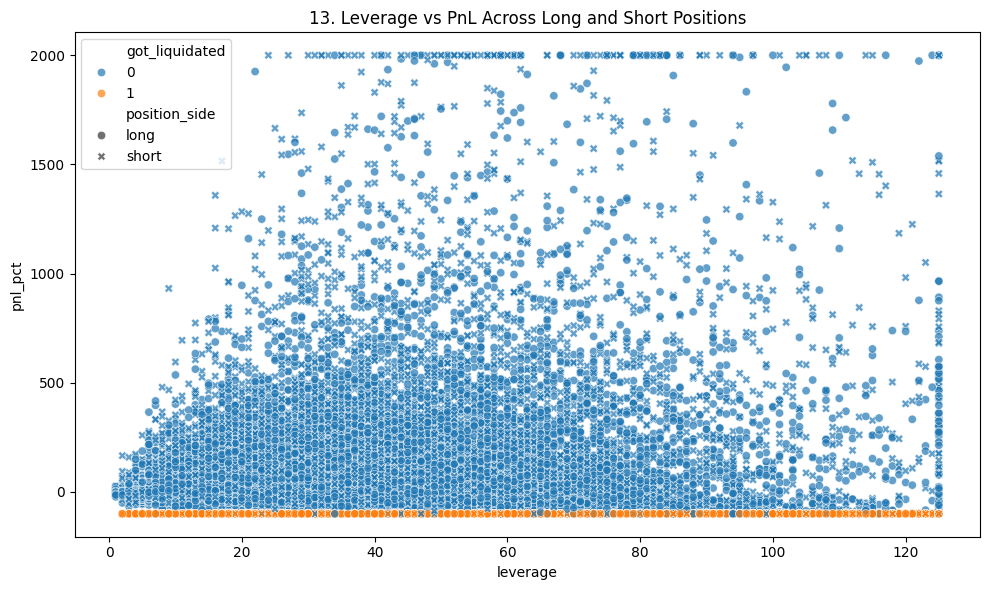

In [26]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='leverage', y='pnl_pct', hue='got_liquidated', style='position_side', alpha=0.7)
plt.title(f'{plot_no}. Leverage vs PnL Across Long and Short Positions')
show_fig()
plot_no += 1

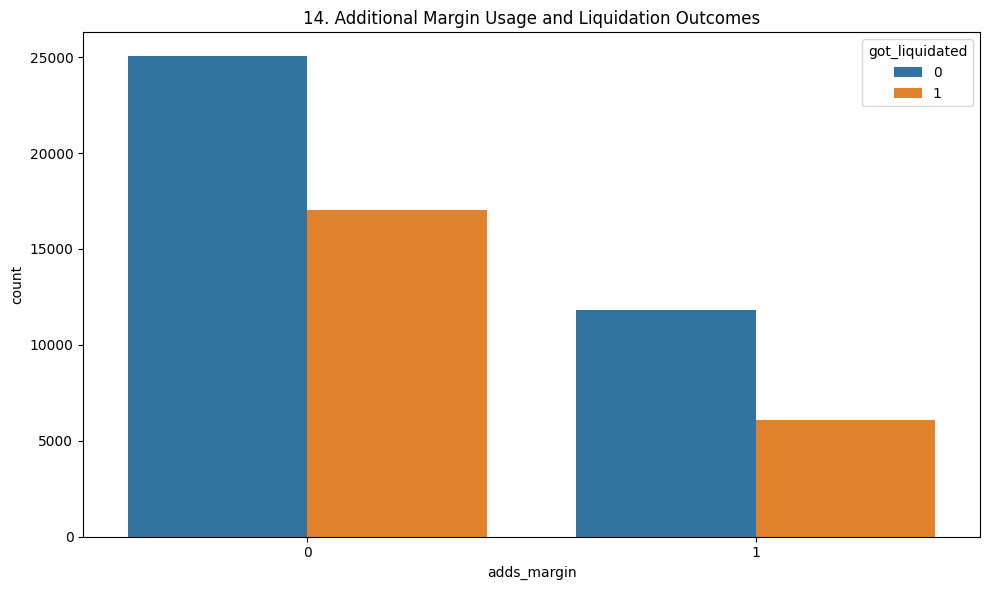

In [27]:
fig = plt.figure(figsize=(10,6))
sns.countplot(data=df, x='adds_margin', hue='got_liquidated')
plt.title(f'{plot_no}. Additional Margin Usage and Liquidation Outcomes')
show_fig()
plot_no += 1

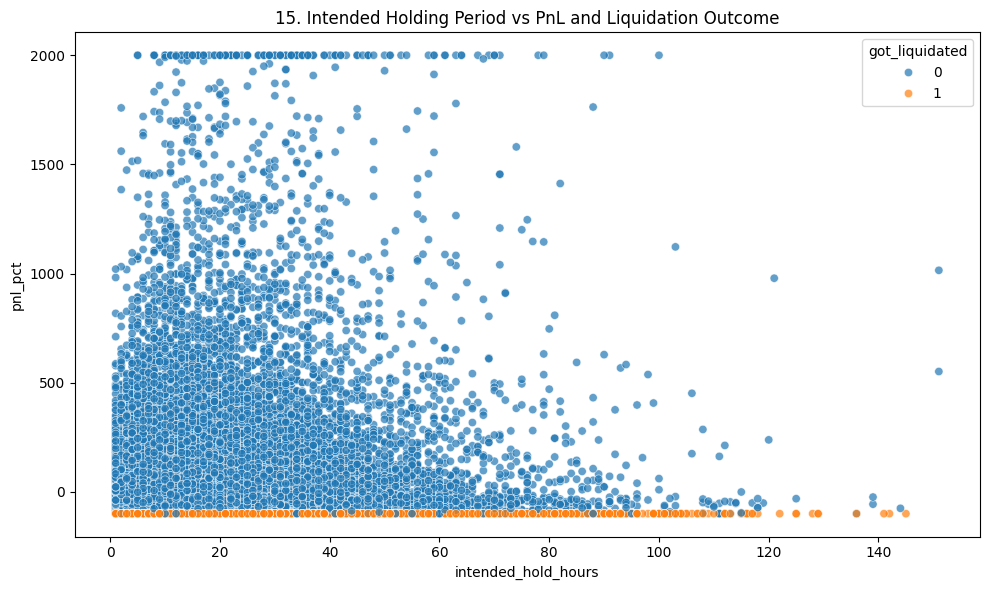

In [28]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='intended_hold_hours', y='pnl_pct', hue='got_liquidated', alpha=0.7)
plt.title(f'{plot_no}. Intended Holding Period vs PnL and Liquidation Outcome')
show_fig()
plot_no += 1

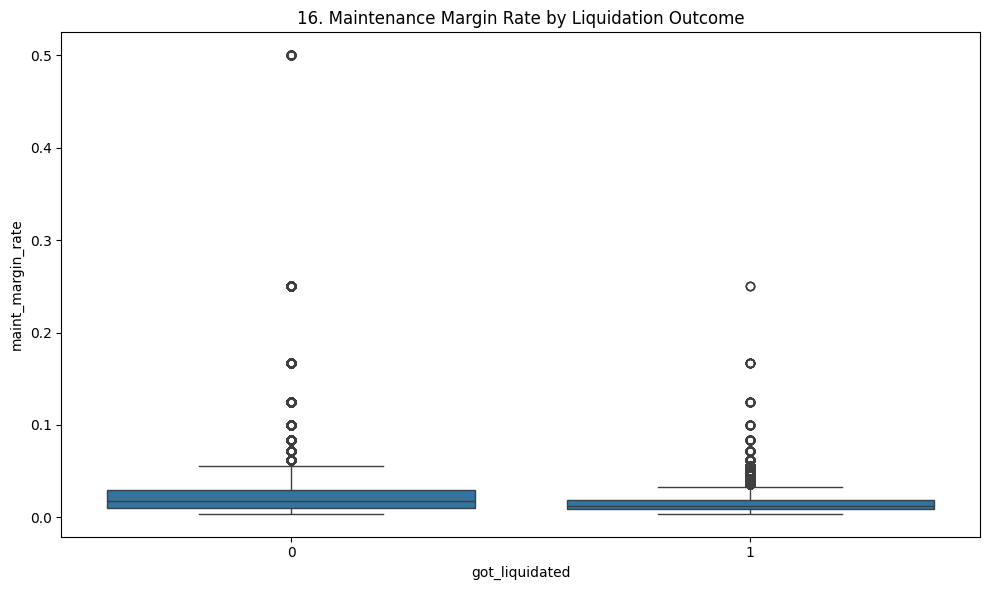

In [29]:
fig = plt.figure(figsize=(10,6))
sns.boxplot(data=df, x='got_liquidated', y='maint_margin_rate')
plt.title(f'{plot_no}. Maintenance Margin Rate by Liquidation Outcome')
show_fig()
plot_no += 1

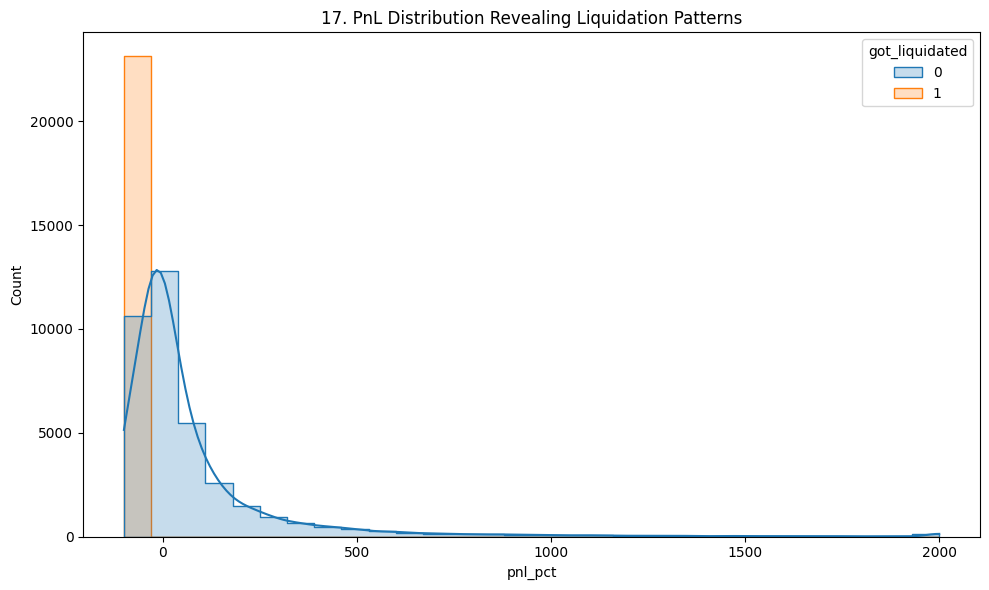

In [30]:
fig = plt.figure(figsize=(10,6))
sns.histplot(data=df, x='pnl_pct', hue='got_liquidated', kde=True, bins=30, element='step')
plt.title(f'{plot_no}. PnL Distribution Revealing Liquidation Patterns')
show_fig()
plot_no += 1

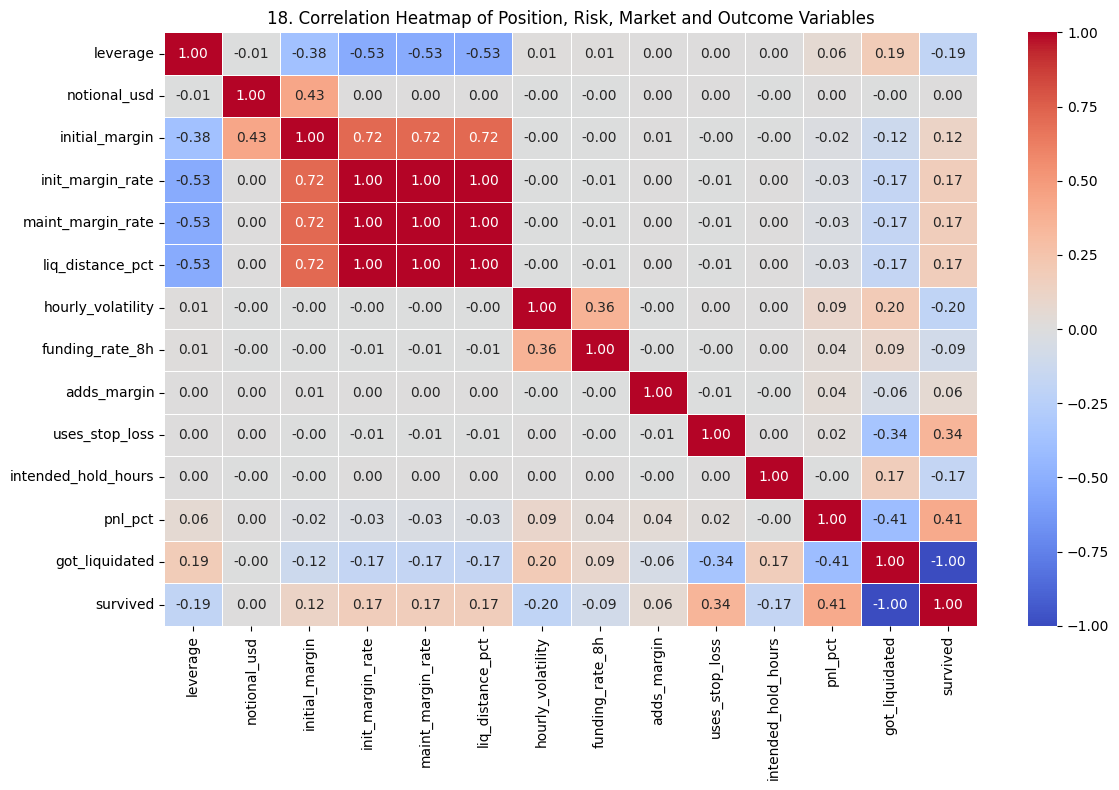

In [31]:
fig = plt.figure(figsize=(12,8))
corr = df.select_dtypes(include='number').corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title(f'{plot_no}. Correlation Heatmap of Position, Risk, Market and Outcome Variables')
show_fig()
plot_no += 1

# Model Training

## Select target and remove identifier

In [32]:
X = df.drop(columns=['got_liquidated', 'survived', 'position_id'])
y = df['got_liquidated']

## Identify numeric and categorical features

In [33]:
numeric_features = X.select_dtypes(include=['int64', 'float64']).columns
categorical_features = X.select_dtypes(include=['object', 'category']).columns

## Prepare numeric preprocessing

In [34]:
numeric_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

## Prepare categorical preprocessing

In [35]:
categorical_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])

## Combine preprocessing steps

In [36]:
preprocessor = ColumnTransformer([
    ('num', numeric_transformer, numeric_features),
    ('cat', categorical_transformer, categorical_features)
])

## Split dataset into training and testing data

In [37]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

## Create Gradient Boosting model

In [38]:
model = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', GradientBoostingClassifier(
        n_estimators=150,
        learning_rate=0.05,
        max_depth=3,
        min_samples_split=10,
        min_samples_leaf=5,
        subsample=0.8,
        random_state=42
    ))
])

## Train the model

In [39]:
model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  Index(['leverage', 'notional_usd', 'initial_margin', 'init_margin_rate',
       'maint_margin_rate', 'liq_distance_pct', 'hourly_volatility',
       'funding_rate_8h', 'adds_margin', 'uses_stop_loss',
       'intended_h...
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  Index(['asset', 'position_side', 'margin_mode', 'vol_regime'], dtype='object'))])),
                ('classifier',
                 GradientBoostingClassifier(learning_rate=0.05,
                                            min_samples_leaf=5,
                                            min_samples_split=10,
                                            n_estimators=150, random_state=42,
                                            subsample=0.8))])

## Generate predictions

In [40]:
y_pred = model.predict(X_test)

## Calculate model accuracy

In [41]:
accuracy = accuracy_score(y_test, y_pred)
print(f"Model Accuracy: {accuracy:.4f}")
print(f"Model Accuracy: {accuracy * 100:.2f}%")

Model Accuracy: 0.9621
Model Accuracy: 96.21%


## Display classification report

In [42]:
print("\nClassification Report:")
print(classification_report(y_test, y_pred))


Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.95      0.97      7375
           1       0.93      0.98      0.95      4625

    accuracy                           0.96     12000
   macro avg       0.96      0.97      0.96     12000
weighted avg       0.96      0.96      0.96     12000



## Plot confusion matrix

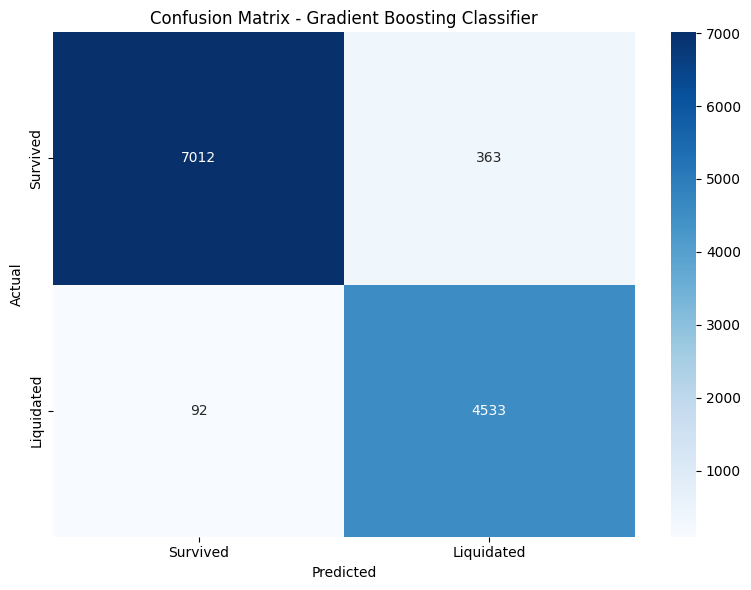

In [43]:
cm = confusion_matrix(y_test, y_pred)

fig = plt.figure(figsize=(8,6))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Survived', 'Liquidated'],
    yticklabels=['Survived', 'Liquidated']
)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - Gradient Boosting Classifier')
plt.tight_layout()
plt.show()